# How did central Plains infrared cloud patterns change over fifteen minutes?

GOES-16 scans two small mesoscale sectors about once a minute, on top of its
routine full-disk and CONUS images. This study takes sector **M1** in channel 13,
the clean longwave infrared window, from **22:00 to 22:15 UTC on 6 May 2024**
(end excluded), and compares a fixed **34–38°N, 100–96°W** region across the
fifteen scenes. The manifest selects whole files; the crop happens locally
after checking every scene's projection, coordinates, and reported footprint.
It answers what changed in observed brightness temperature, without tracking
a particular storm or inferring tornado intensity.

It needs `usdata[netcdf]`, matplotlib, and `pyproj` for the geographic mask. The
committed lockfile pins all fifteen scenes, about 4.9 MB, and the run takes a
few seconds.

In [1]:
from datetime import UTC, datetime
from importlib.metadata import version
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import CRS, Transformer

from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(
    "; ".join(
        f"{name} {version(name)}"
        for name in ("usdata", "xarray", "h5netcdf", "numpy", "pandas", "pyproj")
    )
)

Executed (UTC): 2026-09-24T06:11:51+00:00
usdata 0.26.0; xarray 2026.7.0; h5netcdf 1.8.1; numpy 2.5.2; pandas 3.0.6; pyproj 3.8.0


## Data

One source, [GOES ABI](https://usdata.dev/datasets/noaa/goes-abi/) Level 2 Cloud
and Moisture Imagery (`ABI-L2-CMIPM`), GOES-16, channel 13, sector M1: the
only product here that samples the same region every minute. M1 and M2 share a
bucket prefix, so the manifest names the sector and the adapter filters the
filenames. The window ends a microsecond before 22:15 so that a scan starting
on the minute would not be included. See the
[GOES provider guide](https://docs.usdata.dev/providers/noaa-goes/), NOAA's
[product reference](https://www.ncei.noaa.gov/products/goes-terrestrial-weather-abi-glm),
and the [scan-mode documentation](https://goes-r.noaa.gov/users/abiScanModeInfo.html).

The folder commits `dataset.lock.json`, so `pull` restores the pinned scenes
instead of listing the bucket again.

In [2]:
print(manifest.read_text().strip())

result = pull(manifest)
items = sorted(result.fetched, key=lambda item: item.asset.time.start)
assert items and all("CMIPM1-M6C13_G16" in item.asset.id for item in items)
print("\nScenes:", len(items), "· source bytes:", sum(item.provenance.size for item in items))
print("Restored from the committed lockfile:", result.from_lockfile)
print("First source:", items[0].asset.href)
pd.DataFrame(
    {
        "scan_start_utc": item.asset.time.start.strftime("%H:%M:%S.%f")[:-5],
        "bytes": item.provenance.size,
        "retrieved_utc": item.provenance.retrieved_at.isoformat(timespec="seconds"),
        "checksum": item.provenance.checksum[:23] + "...",
    }
    for item in items
).head()

name: central-plains-mesoscale
sources:
  - name: imagery
    dataset: noaa:goes-abi
    start: 2024-05-06T22:00:00Z
    end: 2024-05-06T22:14:59.999999Z
    params:
      satellite: 16
      channel: 13
      product: ABI-L2-CMIPM
      sector: M1



Scenes: 15 · source bytes: 4925644
Restored from the committed lockfile: True
First source: s3://noaa-goes16/ABI-L2-CMIPM/2024/127/22/OR_ABI-L2-CMIPM1-M6C13_G16_s20241272200280_e20241272200349_c20241272200404.nc


,scan_start_utc,bytes,retrieved_utc,checksum
0,22:00:28.0,329131,2026-09-24T06:11:54+00:00,sha256:4108712cbc4075d1...
1,22:01:25.1,329127,2026-09-24T06:11:56+00:00,sha256:f2404f6f9018d328...
2,22:02:25.1,329109,2026-09-24T06:11:57+00:00,sha256:4422dfb2a64c9b77...
3,22:03:25.1,328798,2026-09-24T06:11:57+00:00,sha256:54669b89b51b4d19...
4,22:04:25.1,328760,2026-09-24T06:11:58+00:00,sha256:80c156b5ba1dc6da...


## Measure the sampling before comparing images

Mesoscale sectors can move between scans, and scan start seconds vary: a minute
of coverage does not imply a scan beginning on the minute. Count occupied UTC
minute bins and show the actual scan-start intervals; do not insert or
interpolate scenes.

In [3]:
starts = pd.DatetimeIndex([item.asset.time.start for item in items])
ends = pd.DatetimeIndex([item.asset.time.end for item in items])
start = pd.Timestamp("2024-05-06T22:00:00Z")
stop = pd.Timestamp("2024-05-06T22:15:00Z")
assert ((starts >= start) & (starts < stop)).all()
assert not starts.duplicated().any(), "Duplicate scan starts need review."
minute_counts = pd.Series(1, index=starts.floor("min")).groupby(level=0).sum()
expected = pd.date_range(start, stop, freq="min", inclusive="left")
missing = expected.difference(minute_counts.index)
print("Missing one-minute bins:", [time.strftime("%H:%M") for time in missing])
print("Scans per occupied minute:", sorted(minute_counts.unique().tolist()))
cadence = pd.DataFrame(
    {
        "start_utc": starts,
        "end_utc": ends,
        "since_previous_seconds": starts.to_series().diff().dt.total_seconds().to_numpy(),
    }
)
print(
    "Start intervals: "
    f"{cadence.since_previous_seconds.min():.1f} to {cadence.since_previous_seconds.max():.1f} s"
)
cadence

Missing one-minute bins: []
Scans per occupied minute: [1]
Start intervals: 57.1 to 62.9 s


,start_utc,end_utc,since_previous_seconds
0,2024-05-06 22:00:28+00:00,2024-05-06 22:00:34.900000+00:00,NaN
1,2024-05-06 22:01:25.100000+00:00,2024-05-06 22:01:32+00:00,57.1
2,2024-05-06 22:02:25.100000+00:00,2024-05-06 22:02:32+00:00,60.0
3,2024-05-06 22:03:25.100000+00:00,2024-05-06 22:03:32.100000+00:00,60.0
4,2024-05-06 22:04:25.100000+00:00,2024-05-06 22:04:32.200000+00:00,60.0
5,2024-05-06 22:05:25.100000+00:00,2024-05-06 22:05:32+00:00,60.0
6,2024-05-06 22:06:25.100000+00:00,2024-05-06 22:06:32+00:00,60.0
7,2024-05-06 22:07:25.100000+00:00,2024-05-06 22:07:32+00:00,60.0
8,2024-05-06 22:08:25.100000+00:00,2024-05-06 22:08:32+00:00,60.0
9,2024-05-06 22:09:25.100000+00:00,2024-05-06 22:09:32.100000+00:00,60.0


## Check the footprint and quality in every file

The local crop is a geographic mask made with the file's geostationary
projection. Check each scan's coordinates, projection, and reported extent
before reusing that mask; abort if the sector moves. Pixel geolocation here
assumes the reference ellipsoid, so elevated clouds can be displaced by
parallax.

Accept only finite `CMI` pixels with `DQF == 0`. Channel 13 supplies brightness
temperature in **kelvin**, not surface air temperature. Report the 10th
percentile and the fraction below **235 K**, an illustrative cold-cloud
threshold. These are pixel summaries within a fixed region, not area-weighted
statistics or storm-intensity measurements. The accepted-pixel denominator is
reported for each scan.

In [4]:
rows, frames, coverage = [], [], []
reference_x = reference_y = reference_projection = reference_extent = None
for item in items:
    with item.open() as scene:
        assert scene.CMI.attrs["units"] == "K" and scene.CMI.dims == ("y", "x")
        assert int(scene.band_id.item()) == 13 and scene.attrs["platform_ID"] == "G16"
        assert pd.Timestamp(scene.attrs["time_coverage_start"]) == pd.Timestamp(
            item.asset.time.start
        )
        assert "good_pixel_qf" in scene.DQF.attrs["flag_meanings"]
        projection = dict(scene.goes_imager_projection.attrs)
        extent = dict(scene.geospatial_lat_lon_extent.attrs)
        if reference_x is None:
            reference_x, reference_y = scene.x.values.copy(), scene.y.values.copy()
            reference_projection, reference_extent = projection, extent
            print("Quality flag values:", scene.DQF.attrs["flag_values"].tolist())
            print("Quality meanings:", scene.DQF.attrs["flag_meanings"])
            transformer = Transformer.from_crs(CRS.from_cf(projection), "EPSG:4326", always_xy=True)
            x, y = np.meshgrid(reference_x, reference_y)
            height = projection["perspective_point_height"]
            lon, lat = transformer.transform(x * height, y * height)
            region = (lon >= -100) & (lon <= -96) & (lat >= 34) & (lat <= 38)
            assert region.any()
            iy, ix = np.where(region)
            ys, xs = slice(iy.min(), iy.max() + 1), slice(ix.min(), ix.max() + 1)
        else:
            assert np.array_equal(scene.x.values, reference_x), "M1 moved: review comparison."
            assert np.array_equal(scene.y.values, reference_y), "M1 moved: review comparison."
            assert projection == reference_projection and extent == reference_extent
        values, flags = scene.CMI.values, scene.DQF.values
        good = region & (flags == 0) & np.isfinite(values)
        accepted = values[good]
        assert accepted.size > 0
        flag_counts = {
            str(int(flag)): int(np.count_nonzero(region & (flags == flag)))
            for flag in np.unique(flags[np.isfinite(flags)])
        }
        rows.append(
            {
                "time": item.asset.time.start,
                "region_pixels": int(region.sum()),
                "accepted_pixels": int(accepted.size),
                "excluded_pixels": int(region.sum() - accepted.size),
                "DQF_counts": flag_counts,
                "missing_DQF": int(np.count_nonzero(region & ~np.isfinite(flags))),
                "p10_K": float(np.quantile(accepted, 0.1)),
                "below_235K_percent": float(100 * np.mean(accepted < 235)),
            }
        )
        coverage.append(
            {
                "time": item.asset.time.start,
                **{
                    key.removeprefix("geospatial_"): float(extent[key])
                    for key in (
                        "geospatial_westbound_longitude",
                        "geospatial_eastbound_longitude",
                        "geospatial_southbound_latitude",
                        "geospatial_northbound_latitude",
                    )
                },
            }
        )
        frames.append(np.where(good, values, np.nan)[ys, xs])
summary = pd.DataFrame(rows).set_index("time")
print("Projection, coordinates, and metadata extent match across all scans.")
print(pd.DataFrame(coverage).head(3).to_string(index=False))
summary[["region_pixels", "accepted_pixels", "excluded_pixels", "p10_K", "below_235K_percent"]]

Quality flag values: [0, 1, 2, 3, 4]
Quality meanings: good_pixel_qf conditionally_usable_pixel_qf out_of_range_pixel_qf no_value_pixel_qf focal_plane_temperature_threshold_exceeded_qf


Projection, coordinates, and metadata extent match across all scans.
                            time  westbound_longitude  eastbound_longitude  southbound_latitude  northbound_latitude
       2024-05-06 22:00:28+00:00          -110.367836           -91.051788            29.716391            43.402351
2024-05-06 22:01:25.100000+00:00          -110.367836           -91.051788            29.716391            43.402351
2024-05-06 22:02:25.100000+00:00          -110.367836           -91.051788            29.716391            43.402351


,region_pixels,accepted_pixels,excluded_pixels,p10_K,below_235K_percent
time,,,,,
2024-05-06 22:00:28+00:00,23968,23968,0,220.085388,16.839119
2024-05-06 22:01:25.100000+00:00,23968,23968,0,219.962494,16.905874
2024-05-06 22:02:25.100000+00:00,23968,23968,0,219.716675,16.997664
2024-05-06 22:03:25.100000+00:00,23968,23968,0,219.593781,17.072764
2024-05-06 22:04:25.100000+00:00,23968,23968,0,219.532318,17.135347
2024-05-06 22:05:25.100000+00:00,23968,23968,0,219.347961,17.289720
2024-05-06 22:06:25.100000+00:00,23968,23968,0,219.286499,17.394025
2024-05-06 22:07:25.100000+00:00,23968,23968,0,219.225067,17.544226
2024-05-06 22:08:25.100000+00:00,23968,23968,0,219.102142,17.698598


## Three scenes on one colour scale

The first, middle, and last scans of the window, cropped to the fixed region
and drawn with the same colour scale. White margins lie outside the geographic
crop, not necessarily in missing source data.

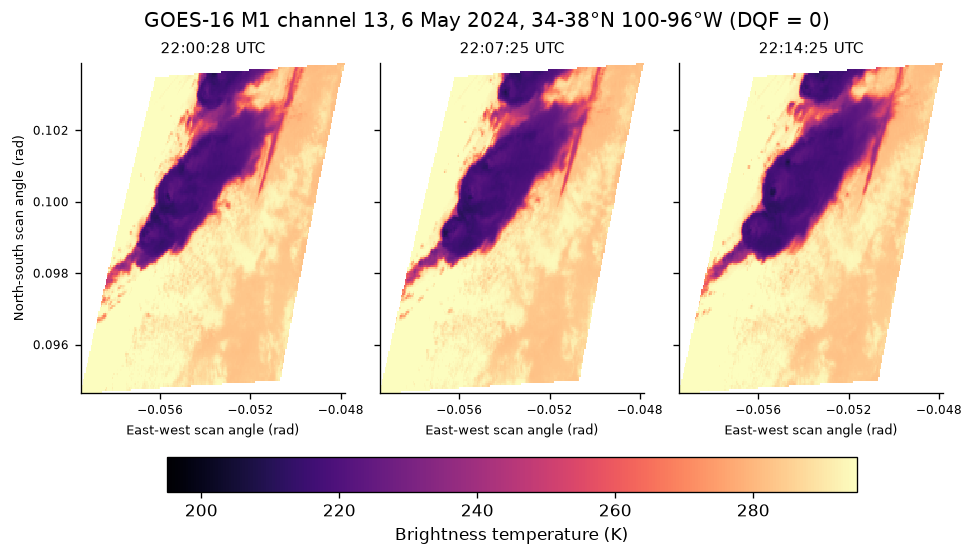

In [5]:
selected = sorted(set([0, len(items) // 2, len(items) - 1]))
fig, axes = plt.subplots(
    1, len(selected), sharex=True, sharey=True, layout="constrained", squeeze=False
)
for axis, index in zip(axes[0], selected, strict=True):
    mesh = axis.pcolormesh(
        reference_x[xs],
        reference_y[ys],
        frames[index],
        shading="auto",
        cmap="magma",
        vmin=195,
        vmax=295,
    )
    axis.grid(False)
    axis.tick_params(labelsize=7)
    axis.xaxis.set_major_locator(plt.MaxNLocator(3))
    axis.set_title(f"{items[index].asset.time.start:%H:%M:%S} UTC", fontsize=9)
    axis.set_xlabel("East-west scan angle (rad)", fontsize=8)
axes[0, 0].set_ylabel("North-south scan angle (rad)", fontsize=8)
fig.colorbar(
    mesh,
    ax=axes.ravel().tolist(),
    label="Brightness temperature (K)",
    shrink=0.8,
    location="bottom",
)
fig.suptitle("GOES-16 M1 channel 13, 6 May 2024, 34-38°N 100-96°W (DQF = 0)")
plt.show()
plt.close(fig)

## What changed in the region

Two summaries per scan, plotted as points so that the irregular sampling shows
and nothing bridges an absent scan.

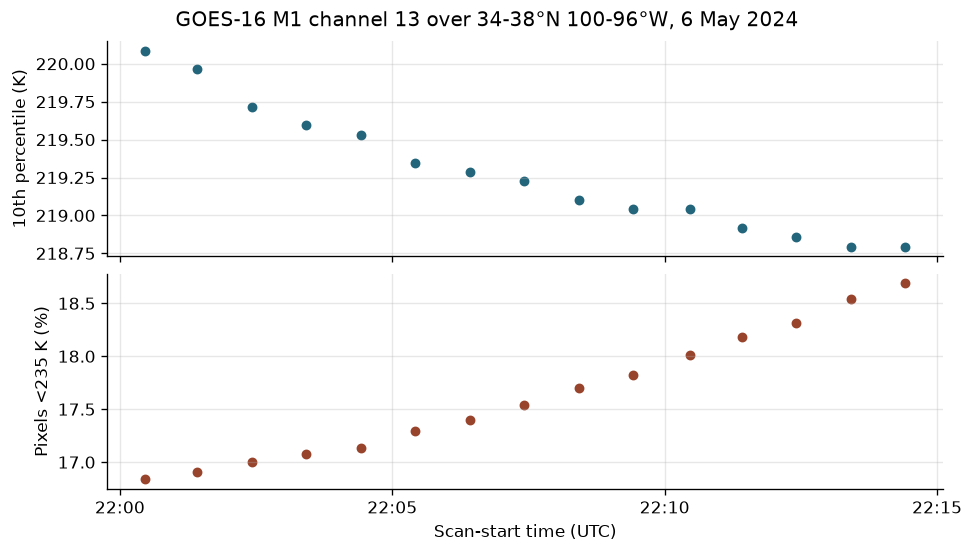

10th percentile: 220.09 → 218.79 K
Cold-pixel fraction: 16.84 → 18.69%


In [6]:
fig, axes = plt.subplots(2, 1, sharex=True, layout="constrained")
axes[0].scatter(summary.index, summary.p10_K, color="#23657b", s=24)
axes[0].set_ylabel("10th percentile (K)")
axes[1].scatter(summary.index, summary.below_235K_percent, color="#98442c", s=24)
axes[1].set_ylabel("Pixels <235 K (%)")
axes[1].set_xlabel("Scan-start time (UTC)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=UTC))
for axis in axes:
    for time in missing:
        axis.axvspan(time, time + pd.Timedelta(minutes=1), color="gray", alpha=0.2)
fig.suptitle("GOES-16 M1 channel 13 over 34-38°N 100-96°W, 6 May 2024")
plt.show()
plt.close(fig)
print(f"10th percentile: {summary.p10_K.iloc[0]:.2f} → {summary.p10_K.iloc[-1]:.2f} K")
print(
    f"Cold-pixel fraction: {summary.below_235K_percent.iloc[0]:.2f} → "
    f"{summary.below_235K_percent.iloc[-1]:.2f}%"
)

The region's coldest tenth of pixels cooled by about 1.3 K and the share of
accepted pixels below 235 K rose by nearly two percentage points, steadily from
scan to scan, while every scan kept all 23,968 region pixels. Cloud motion into
or out of the region, growth, and changing valid-pixel coverage can all alter
these summaries, and this study does not distinguish those mechanisms.
Channel-13 brightness temperature is not surface air temperature, and
ellipsoid-based cloud positions have parallax uncertainty.

## Pin and cite

`verify` checks every cached scene against the committed lockfile's checksums,
and the citation below is what a methods section needs; `usdata cite
dataset.yaml` prints the same. The raw NetCDF files are unchanged; the lockfile
records their URLs, retrieval times, sizes, and checksums.

The folder's lockfile is committed and joins the project's weekly empty-cache
restore checks. Re-pinning is an explicit, reviewed operation, never part of
running the notebook. Keep the manifest, the lockfile, and the cached NetCDF
files together.

In [7]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:goes-abi
  NOAA Geostationary Operational Environmental Satellites (GOES) 16, 17, 18 & 19 was accessed on 2026-09-22 from https://registry.opendata.aws/noaa-goes
  homepage: https://registry.opendata.aws/noaa-goes/
  license: US Government Work (public domain)
  terms: https://www.noaa.gov/information-technology/open-data-dissemination
  retrieved: 2026-09-22; 15 checksummed assets (4,925,644 bytes) pinned by usdata 0.24.0
  sources: imagery


The cell below restores all fifteen scenes into a second, empty cache and
compares their bytes with the first copy.

In [8]:
original = {item.asset.id: item for item in items}
with TemporaryDirectory(prefix="usdata-mesoscale-restore-") as fresh:
    restored = pull(manifest, root=fresh)
    assert restored.from_lockfile and not any(item.from_cache for item in restored.fetched)
    assert restored.lockfile == result.lockfile
    assert {item.asset.id for item in restored.fetched} == set(original)
    assert verify(manifest, root=fresh) == []
    for item in restored.fetched:
        assert item.path.read_bytes() == original[item.asset.id].path.read_bytes()
print(f"All {len(items)} pinned scenes restored byte-for-byte into an empty cache.")

All 15 pinned scenes restored byte-for-byte into an empty cache.


## What was awkward

- M1 and M2 share a bucket prefix. Choosing a product alone cannot select one
  sector, and a sector name does not tell you where it was pointed historically.
- Start seconds shift around the minute. Missing minute bins and actual time
  differences are reported separately; the analysis does not fill gaps.
- Fixed pixel indices are comparable only after checking that the sector did
  not move. The notebook stops if its coordinates or projection change.
- The geographic crop belongs to the analysis and needs projection handling;
  the archive still downloads complete scenes.
- A cold-cloud threshold describes a chosen subset of infrared pixels. It
  cannot by itself separate storm growth, movement, and changing coverage.